# Pipeline de features

Genera un escenario de anomalia con `predictive_monitoring_tool.data.generator.generate()` y le aplica `predictive_monitoring_tool.data.features.build_features()` para obtener el dataset de features listo para modelar (rolling, lags, diff, features temporales). Grafica la metrica cruda vs. su media movil de 5 minutos, marcando la ventana de anomalia inyectada.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from predictive_monitoring_tool.data.features import build_features
from predictive_monitoring_tool.data.generator import generate

DURATION_MINUTES = 180
SEED = 42


## Escenario: `memory_leak`

Genera 180 minutos de datos con una ventana de `memory_leak` de 60 minutos a partir del minuto 30, y le aplica `build_features()` con los `windows` por default (`5min`, `15min`).

In [2]:
start_minute, window_minutes = 30, 60
df_raw = generate(
    DURATION_MINUTES,
    scenario="memory_leak",
    scenario_start_minute=start_minute,
    anomaly_duration_minutes=window_minutes,
    seed=SEED,
)
df_features = build_features(df_raw)

print(f"df_raw: {df_raw.shape}, df_features: {df_features.shape}")
df_features.columns.tolist()


df_raw: (1080, 7), df_features: (1075, 45)


['cpu_pct',
 'memory_pct',
 'disk_pct',
 'latency_ms',
 'requests_per_sec',
 'is_anomaly',
 'scenario',
 'cpu_pct_rolling_mean_5min',
 'cpu_pct_rolling_std_5min',
 'cpu_pct_rolling_mean_15min',
 'cpu_pct_rolling_std_15min',
 'memory_pct_rolling_mean_5min',
 'memory_pct_rolling_std_5min',
 'memory_pct_rolling_mean_15min',
 'memory_pct_rolling_std_15min',
 'disk_pct_rolling_mean_5min',
 'disk_pct_rolling_std_5min',
 'disk_pct_rolling_mean_15min',
 'disk_pct_rolling_std_15min',
 'latency_ms_rolling_mean_5min',
 'latency_ms_rolling_std_5min',
 'latency_ms_rolling_mean_15min',
 'latency_ms_rolling_std_15min',
 'requests_per_sec_rolling_mean_5min',
 'requests_per_sec_rolling_std_5min',
 'requests_per_sec_rolling_mean_15min',
 'requests_per_sec_rolling_std_15min',
 'cpu_pct_lag_1',
 'cpu_pct_lag_5',
 'memory_pct_lag_1',
 'memory_pct_lag_5',
 'disk_pct_lag_1',
 'disk_pct_lag_5',
 'latency_ms_lag_1',
 'latency_ms_lag_5',
 'requests_per_sec_lag_1',
 'requests_per_sec_lag_5',
 'cpu_pct_diff',
 'm

## Metrica cruda vs. media movil

`memory_pct` crudo vs. `memory_pct_rolling_mean_5min`, con la ventana de anomalia resaltada (`axvspan`, misma convencion que el notebook 01).

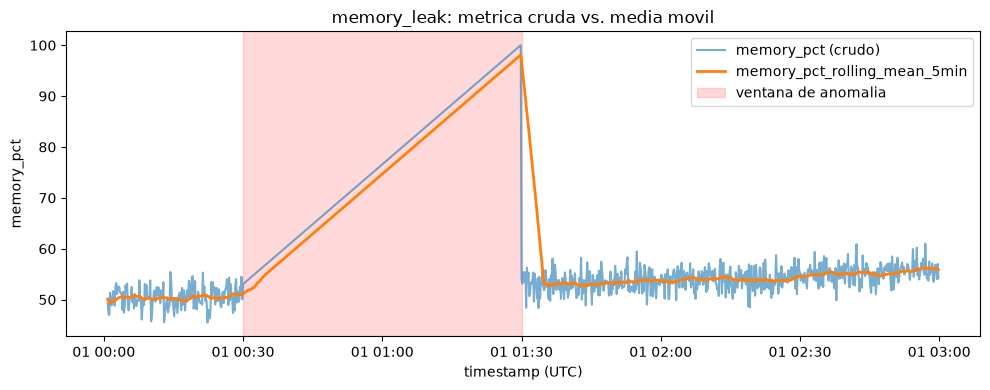

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    df_features.index, df_features["memory_pct"],
    label="memory_pct (crudo)", alpha=0.6,
)
ax.plot(
    df_features.index,
    df_features["memory_pct_rolling_mean_5min"],
    label="memory_pct_rolling_mean_5min",
    linewidth=2,
)
ax.axvspan(
    df_raw.index[0] + pd.Timedelta(minutes=start_minute),
    df_raw.index[0] + pd.Timedelta(minutes=start_minute + window_minutes),
    color="red", alpha=0.15, label="ventana de anomalia",
)
ax.set_ylabel("memory_pct")
ax.set_xlabel("timestamp (UTC)")
ax.set_title("memory_leak: metrica cruda vs. media movil")
ax.legend()
fig.tight_layout()
plt.show()


## Resumen de features generadas

Columnas nuevas agrupadas por tipo (rolling, lag, diff, temporales), sobre las 5 metricas crudas + `is_anomaly` + `scenario` originales.

In [4]:
feature_groups = {
    "rolling": [c for c in df_features.columns if "_rolling_" in c],
    "lag": [c for c in df_features.columns if "_lag_" in c],
    "diff": [c for c in df_features.columns if c.endswith("_diff")],
    "temporal": ["hour", "day_of_week", "is_business_hours"],
}
for name, cols in feature_groups.items():
    print(f"{name} ({len(cols)}): {cols}")


rolling (20): ['cpu_pct_rolling_mean_5min', 'cpu_pct_rolling_std_5min', 'cpu_pct_rolling_mean_15min', 'cpu_pct_rolling_std_15min', 'memory_pct_rolling_mean_5min', 'memory_pct_rolling_std_5min', 'memory_pct_rolling_mean_15min', 'memory_pct_rolling_std_15min', 'disk_pct_rolling_mean_5min', 'disk_pct_rolling_std_5min', 'disk_pct_rolling_mean_15min', 'disk_pct_rolling_std_15min', 'latency_ms_rolling_mean_5min', 'latency_ms_rolling_std_5min', 'latency_ms_rolling_mean_15min', 'latency_ms_rolling_std_15min', 'requests_per_sec_rolling_mean_5min', 'requests_per_sec_rolling_std_5min', 'requests_per_sec_rolling_mean_15min', 'requests_per_sec_rolling_std_15min']
lag (10): ['cpu_pct_lag_1', 'cpu_pct_lag_5', 'memory_pct_lag_1', 'memory_pct_lag_5', 'disk_pct_lag_1', 'disk_pct_lag_5', 'latency_ms_lag_1', 'latency_ms_lag_5', 'requests_per_sec_lag_1', 'requests_per_sec_lag_5']
diff (5): ['cpu_pct_diff', 'memory_pct_diff', 'disk_pct_diff', 'latency_ms_diff', 'requests_per_sec_diff']
temporal (3): ['hour'